In [1]:
# ============================================================
# Setup & imports
# ============================================================
%load_ext autoreload
%autoreload 2

import glob, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import scvi
import anndata
import torch
from functools import partial
from sklearn.neighbors import NearestNeighbors
from scipy.stats import kruskal

# local modules (require the repo root on sys.path)
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))
from notebooks.config import *
import processing, utils, plotting, heatmap, transcriptomics_analysis
import pseudoclusters, test_structures
import batch_checking, pseudobulk

# matplotlib + figure-saving config
configure_matplotlib()
SAVE_FIGURES = True
fig_path = RETROSEQ_FIGURE_DIR
save_figure = partial(save_figure, dir_path=fig_path)
cpm_scl = CPM_SCL

print(f"scanpy version: {sc.__version__}")
print(f"scvi version:   {scvi.__version__}")
print("GPU:", torch.cuda.get_device_name(torch.cuda.current_device()))

PROJECT_ROOT: /code/
CODE_DIR: /code/
CODE_DIR exists: True
Python path includes CODE_DIR: True
scanpy version: 1.11.3
scvi version:   1.3.3
GPU: Tesla T4


# Load & preprocess data (retroseq + snRNA)

In [2]:
print("Loading retroseq and snRNA data...")
filename = os.path.join(RETROSEQ_DATA_DIR, 'retroseq_updated_filtered.h5ad')
adata_retro = sc.read_h5ad(filename)

# Load snRNA data for gene filtering
myfilename = os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad")
adata_sc = sc.read_h5ad(myfilename)
adata_sc.obs['sex'] = adata_sc.obs['sex'].replace({'M;M;M;M;M;M;M;M;M;M': 'M', 'F;F;F;F;F;F;F;F;F;F': 'F'})

# Filter genes to match snRNA data
keepgenes = np.intersect1d(list(adata_sc.var_names), list(adata_retro.var_names))
print(f"Number of shared genes: {keepgenes.shape[0]}")
adata_retro = adata_retro[:, keepgenes].copy()
adata_retro.raw = adata_retro.copy() # the raw now will preserve the not-length-normalized versions


# # length normalizations (GENCODE vM38 annotation comes from the data asset; see config.GENCODE_GTF)
gene_lengths = transcriptomics_analysis.gene_lengths_from_gtf(GENCODE_GTF)
adata_retro.var["gene_length_bp"] = adata_retro.var_names.map(gene_lengths)
adata_retro.var["gene_length_bp"] = adata_retro.var["gene_length_bp"].fillna(adata_retro.var["gene_length_bp"].median())
X_foo = transcriptomics_analysis.tpm_normalize(adata_retro.X, adata_retro.var["gene_length_bp"].values)
adata_retro.X = np.around(X_foo.toarray()).astype(int)


# Check normalization of reference dataset
print(f"Reference dataset sum per cell: {np.mean(np.sum(adata_sc.layers['BN'], 1)):.4f}")

Loading retroseq and snRNA data...
Number of shared genes: 1439
Reference dataset sum per cell: 1.0000


# Batch-effect analysis

No batch correction is applied to the retroseq data; these cells check whether any is warranted.

**1. Metadata screen** (`screen_metadata_for_batch`) ranks obs columns by batch-effect potential:
- `cramers_v_site` — association/confounding with `injection_site` (the biology)
- `pct_levels_one_site` — fraction of the column's levels confined to a single site
- `nested_in_mouse` — `1.0` ⇒ already absorbed by the mouse term (not a *new* batch)
- `cramers_v_mouse` — association with mouse ID (context)

A column with high `cramers_v_site` **and** low `nested_in_mouse` is a candidate batch worth adding to the Random-Forest targets.

**2. Random-Forest detection** under two CV schemes: random per-cell (optimistic — cells from one mouse leak across folds) vs. GroupKFold by mouse (honest for this nested design — whole mice are held out, so `injection_site` counts only if it *generalizes* across mice). If the signal clears the chance line per-cell but collapses under GroupKFold, it was individual-mouse memorization, not a real injection-site batch.

In [3]:
# eyeball low-cardinality obs columns (sequencing-run / library / plate, etc.)
obs_overview = (
    adata_retro.obs.nunique(dropna=True).rename('n_levels').to_frame()
    .assign(dtype=adata_retro.obs.dtypes.astype(str))
    .sort_values('n_levels')
)
display(obs_overview[obs_overview['n_levels'].between(2, 30)])  # candidate batch range

# rank candidates by batch-effect potential (columns explained in the markdown above)
batch_screen = batch_checking.screen_metadata_for_batch(
    adata_retro, bio_col='injection_site', mouse_col='external_donor_name')
display(batch_screen)

,n_levels,dtype
S4.Lot,2,category
Exclude.STAR,2,category
library_prep_pass_fail,2,category
pcr_cycles,2,category
rna_amplification_pass_fail,2,category
NexteraLot,2,category
experiment_component_failed,2,bool
gender,2,category
Seq_Amp,2,category
injection_site,4,category


,n_levels,cramers_v_site,pct_levels_one_site,nested_in_mouse,cramers_v_mouse
injection_roi,9,0.997665,1.000000,1.000000,0.995303
rna_amplification_set,26,0.685054,0.461538,0.157895,0.582151
library_prep_set,26,0.685054,0.461538,0.157895,0.582151
age,7,0.664601,0.571429,1.000000,0.994371
lib_date,14,0.628737,0.285714,0.210526,0.565570
FACS.Date,5,0.613061,0.200000,1.000000,0.993443
batch,11,0.611489,0.272727,0.157895,0.607086
tube_avg_size_bp,11,0.611489,0.272727,0.157895,0.607086
tube_contents_nm_from_vendor,11,0.611489,0.272727,0.157895,0.607086
tube_contents_nm,11,0.611489,0.272727,0.157895,0.607086


*** batch effect by mouse ID, per projection target ***
frontal cortex: (173, 1439)
cerebellum: (210, 1439)
spinal cord: (183, 1439)
thalamus: (510, 1439)

frontal cortex


/tmp/ipykernel_12147/3455982304.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


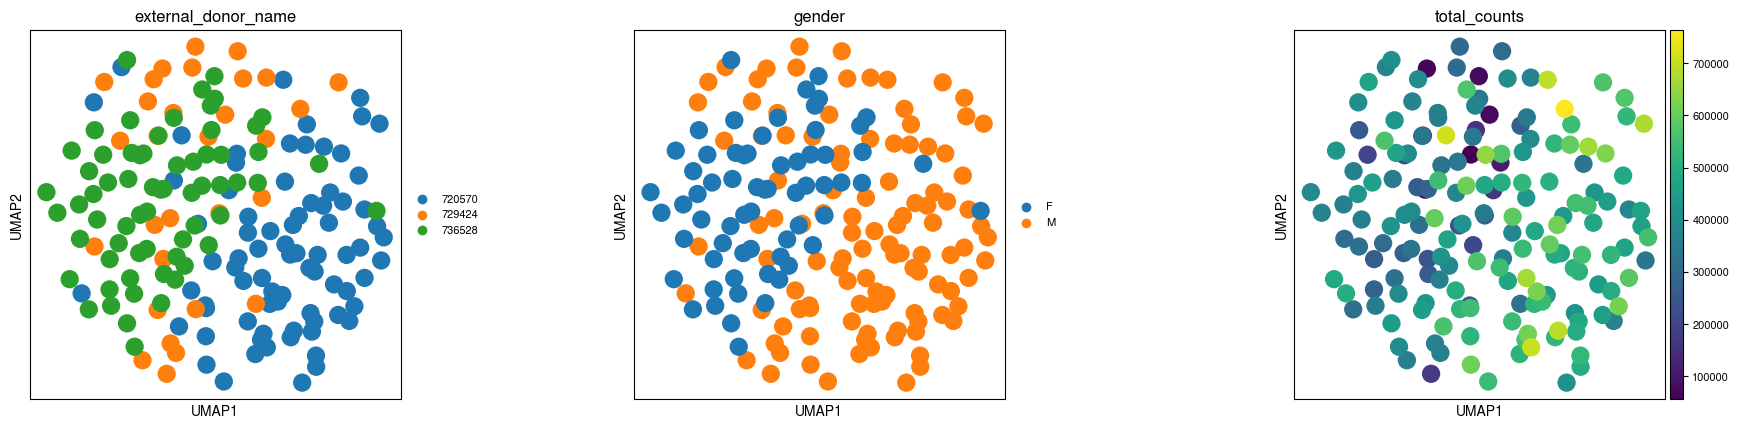


cerebellum


/tmp/ipykernel_12147/3455982304.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


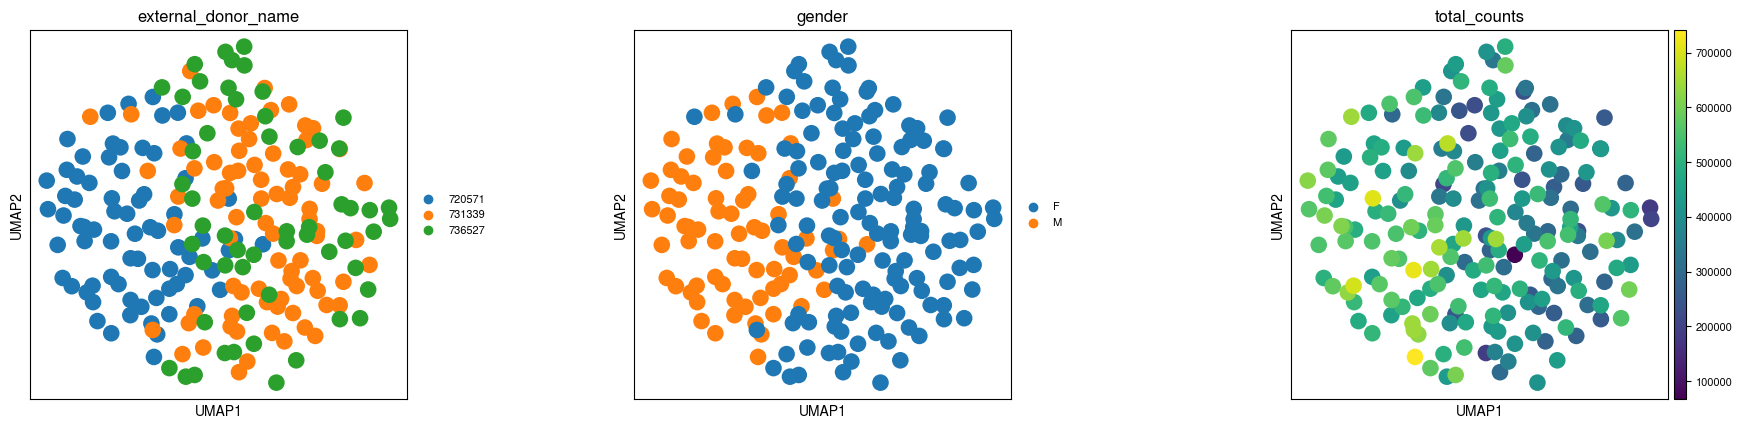


spinal cord


/tmp/ipykernel_12147/3455982304.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


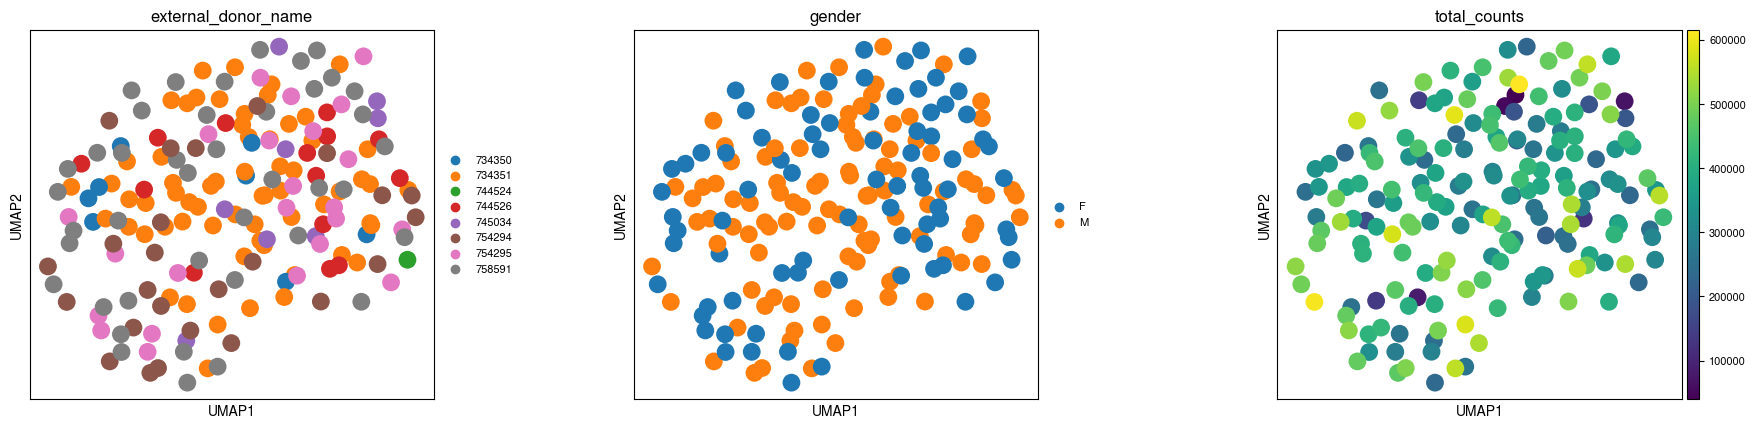


thalamus


/tmp/ipykernel_12147/3455982304.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


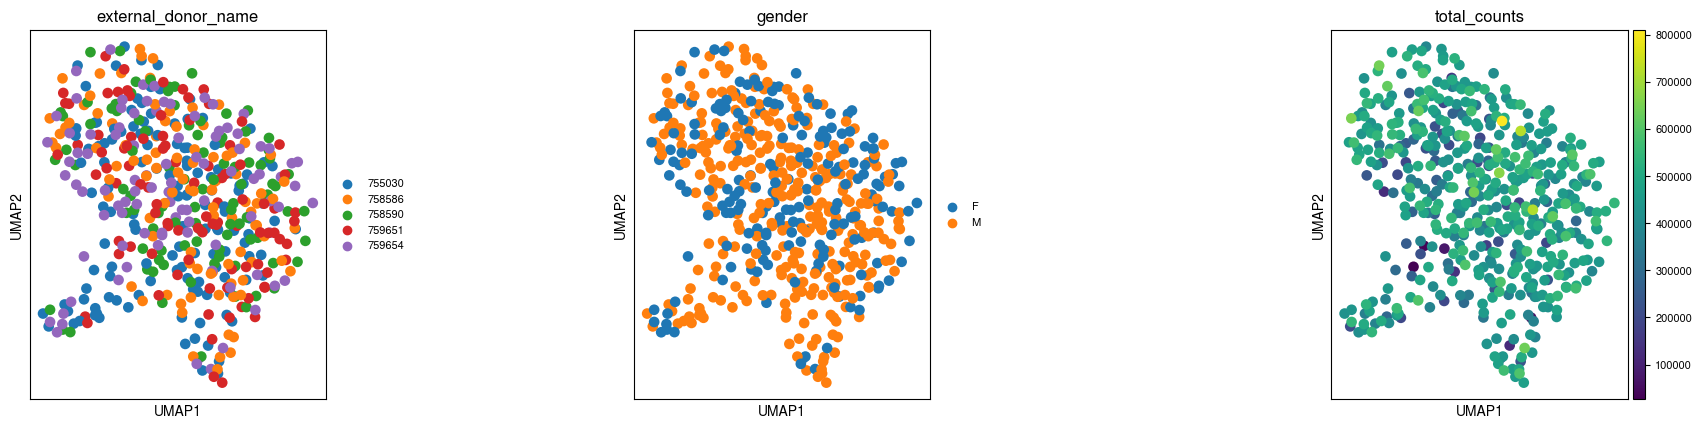


*** all samples ***


/tmp/ipykernel_12147/3455982304.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


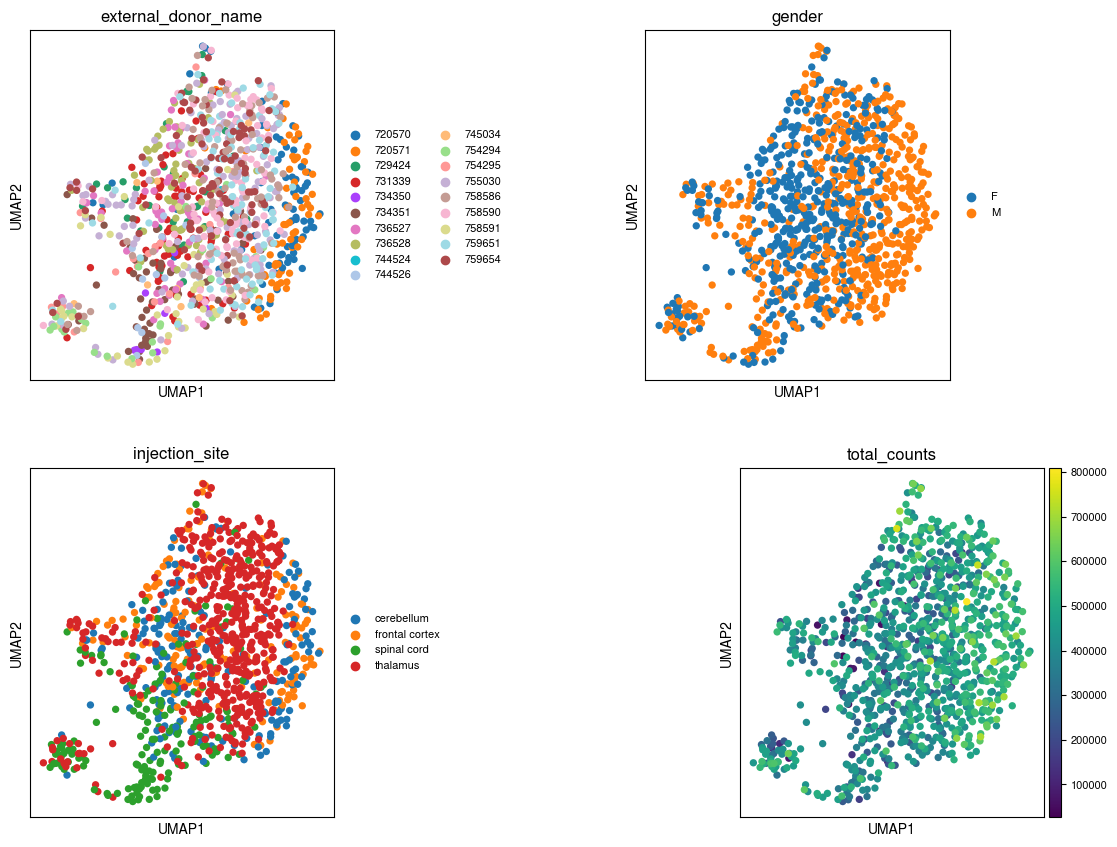


*** Random Forest: per-cell CV vs GroupKFold by mouse ***
gender balanced_accuracy: 0.978 ± 0.004 (chance 0.500, majority 0.562; StratifiedKFold(5 folds, shuffle))
  [external_donor_name] dropping 1 cells in classes with < 2 cells
external_donor_name balanced_accuracy: 0.417 ± 0.007 (chance 0.056, majority 0.124; StratifiedKFold(5 folds, shuffle))
injection_site balanced_accuracy: 0.553 ± 0.016 (chance 0.250, majority 0.474; StratifiedKFold(5 folds, shuffle))


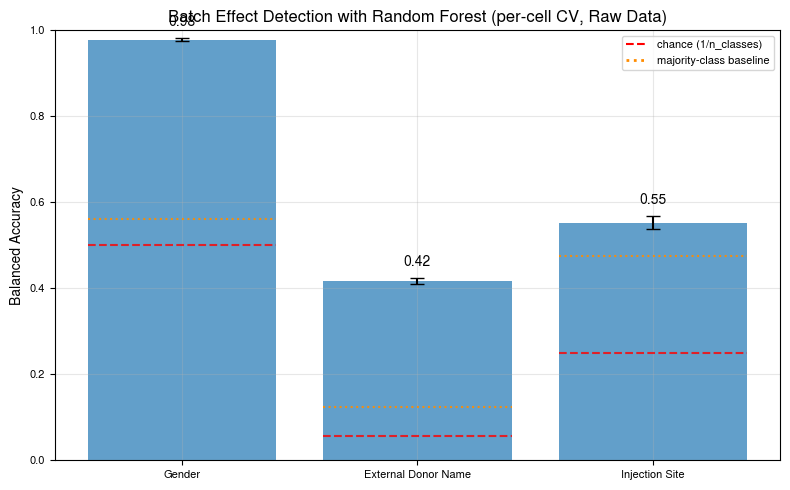

gender balanced_accuracy: 0.976 ± 0.020 (chance 0.500, majority 0.562; GroupKFold(by external_donor_name, 5 folds))
  [external_donor_name] dropping 1 cells in classes with < 2 cells


/code/batch_checking.py:260: UserWarning: group_col == 'external_donor_name'; cannot hold out the group being predicted -- falling back to StratifiedKFold for this target.
  warnings.warn(f"group_col == '{var}'; cannot hold out the group being "


external_donor_name balanced_accuracy: 0.417 ± 0.007 (chance 0.056, majority 0.124; StratifiedKFold(5 folds, shuffle))


/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


injection_site balanced_accuracy: 0.475 ± 0.087 (chance 0.250, majority 0.474; GroupKFold(by external_donor_name, 5 folds))


/opt/conda/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


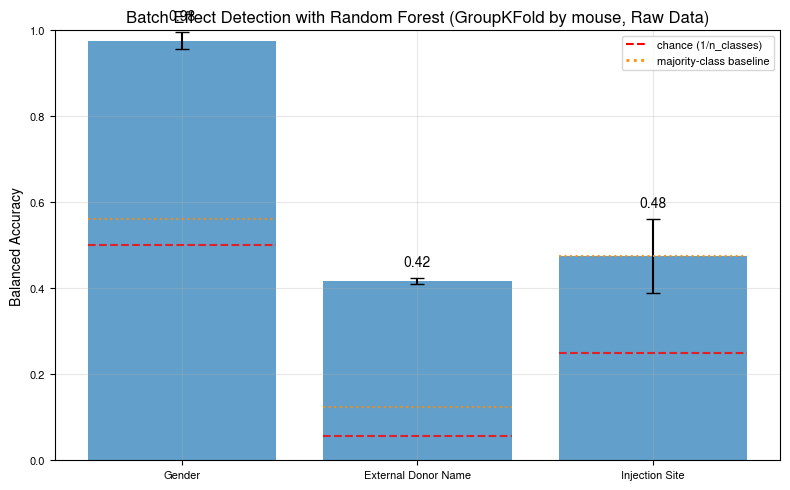

{'per_cell': {'gender': {'scores': array([0.97933884, 0.97107438, 0.97933884, 0.98347107, 0.97815193]),
   'mean': 0.9782750131879725,
   'std': 0.004028071152934108,
   'chance_level': 0.5,
   'majority_baseline': 0.5622676579925651,
   'n_classes': 2,
   'scoring': 'balanced_accuracy',
   'cv': 'StratifiedKFold(5 folds, shuffle)'},
  'external_donor_name': {'scores': array([0.40778526, 0.43007342, 0.41762874, 0.41280364, 0.41498156]),
   'mean': 0.4166545240010152,
   'std': 0.007447250700118128,
   'chance_level': 0.05555555555555555,
   'majority_baseline': 0.12372093023255815,
   'n_classes': 18,
   'scoring': 'balanced_accuracy',
   'cv': 'StratifiedKFold(5 folds, shuffle)'},
  'injection_site': {'scores': array([0.54360474, 0.55464519, 0.57840803, 0.53067984, 0.55765009]),
   'mean': 0.5529975774093421,
   'std': 0.015851551391920102,
   'chance_level': 0.25,
   'majority_baseline': 0.4739776951672863,
   'n_classes': 4,
   'scoring': 'balanced_accuracy',
   'cv': 'StratifiedKFo

In [4]:
def run_comprehensive_batch_analysis(adata):
    """UMAP + Random-Forest batch-effect diagnostics (see markdown above)."""
    # per-projection-target UMAPs colored by mouse ID / sex / sequencing depth
    print("*** batch effect by mouse ID, per projection target ***")
    for group_name, adata_subset in batch_checking.create_projection_subsets(adata, 'injection_site').items():
        print(f"\n{group_name}")
        sc.tl.umap(adata_subset, random_state=210)
        ax = sc.pl.umap(adata_subset, color=["external_donor_name", "gender", 'total_counts'], ncols=3, show=False)
        for a in ax: a.set_aspect('equal')
        plt.tight_layout(); plt.show()

    # all samples together
    print("\n*** all samples ***")
    adata_processed = batch_checking.preprocess_full_dataset(adata)
    ax = sc.pl.umap(adata_processed, color=["external_donor_name", "gender", 'injection_site', 'total_counts'], ncols=2, show=False)
    for a in ax: a.set_aspect('equal')
    plt.tight_layout(); plt.show()

    # Random Forest: per-cell CV (optimistic) vs GroupKFold by mouse (honest, nested design)
    print("\n*** Random Forest: per-cell CV vs GroupKFold by mouse ***")
    rf_percell = batch_checking.evaluate_batch_effects_rf(adata)
    batch_checking.plot_rf_results(rf_percell, " (per-cell CV, Raw Data)"); plt.show()
    rf_bymouse = batch_checking.evaluate_batch_effects_rf(adata, group_col='external_donor_name')
    batch_checking.plot_rf_results(rf_bymouse, " (GroupKFold by mouse, Raw Data)"); plt.show()
    return {'per_cell': rf_percell, 'by_mouse': rf_bymouse}


run_comprehensive_batch_analysis(adata_retro)

# PCA & UMAP embeddings

In [5]:

mapping = {
    cat: cat.title()
    for cat in adata_retro.obs['injection_site'].cat.categories}

adata_retro.obs['injection_site'] = (
    adata_retro.obs['injection_site']
    .cat.rename_categories(mapping))

/tmp/ipykernel_12147/2336586456.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


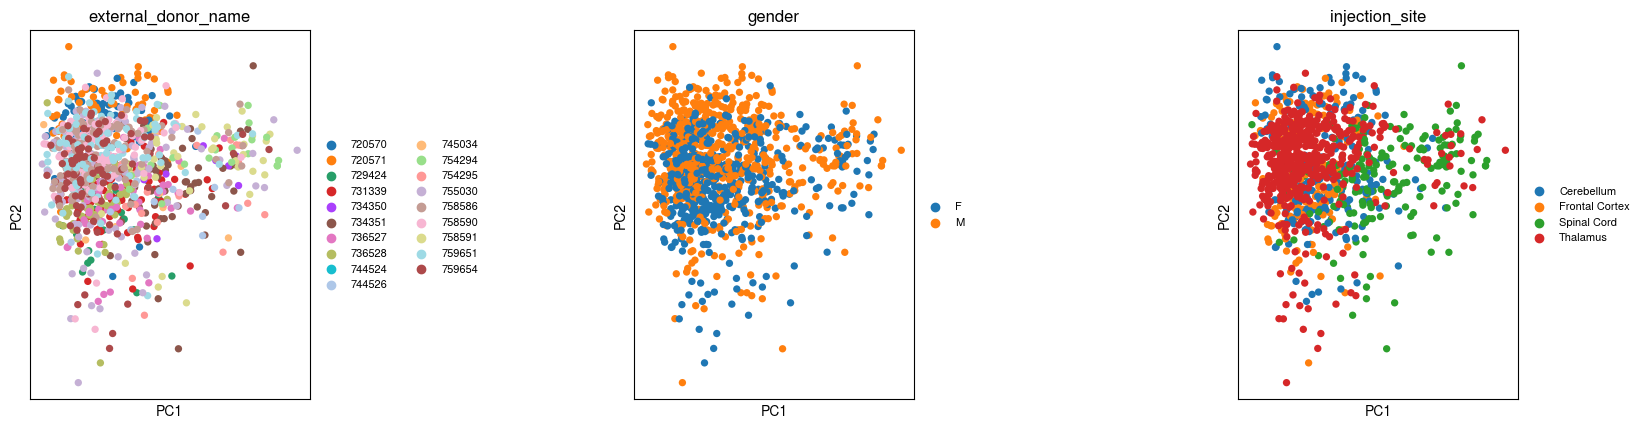

In [6]:
# Idempotent: process a throwaway copy so adata_retro.X stays the raw counts.
adata_proc = adata_retro.copy()
sc.pp.normalize_total(adata_proc, target_sum=1e6)
sc.pp.log1p(adata_proc)
sc.pp.scale(adata_proc, zero_center=True, max_value=10)
zero_center_pca = True
sc.tl.pca(adata_proc, n_comps=50, svd_solver="arpack", zero_center=zero_center_pca)

# keep adata_retro.X intact; store the PCA input as a layer + results in obsm/varm/uns
adata_retro.layers["pca_input"] = adata_proc.X.copy()   # scaled log-CPM used for PCA
adata_retro.obsm["X_pca"] = adata_proc.obsm["X_pca"]
adata_retro.varm["PCs"] = adata_proc.varm["PCs"]
adata_retro.uns["pca"] = adata_proc.uns["pca"]

ax = sc.pl.pca(adata_retro,
    color=["external_donor_name", "gender", "injection_site"],ncols=3,show=False)
for a in ax:
    a.set_aspect("equal")
plt.tight_layout()


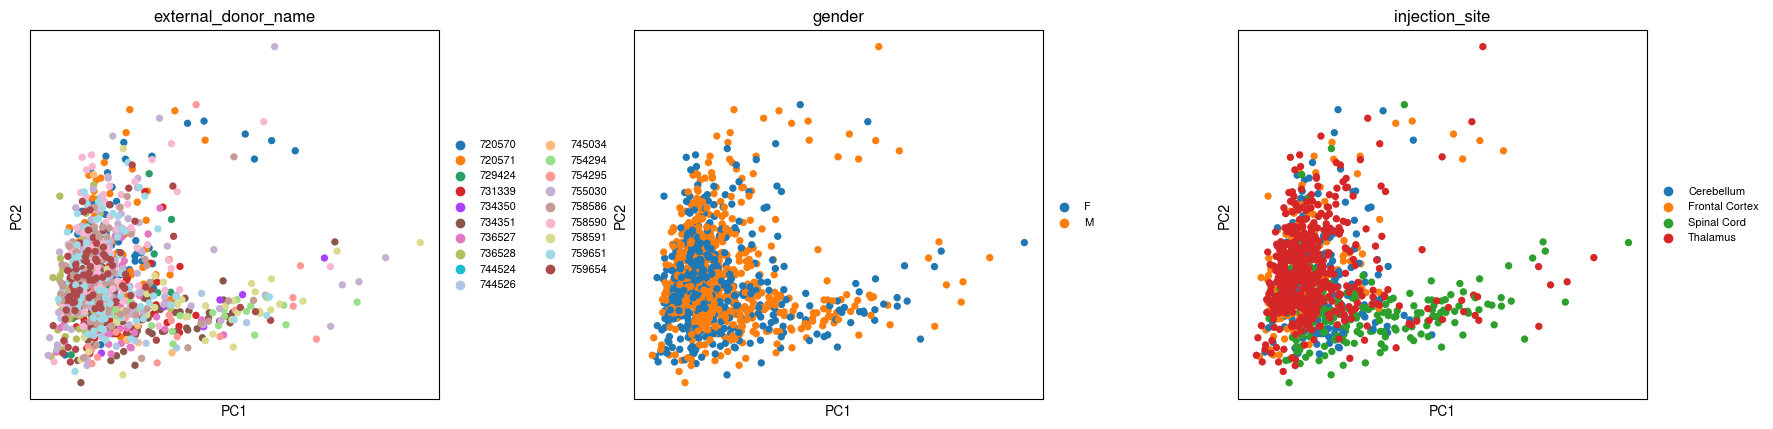

In [7]:
# PCA Visualizatio
adata_pca = adata_retro.copy()  # so its library size of 1
sc.pp.scale(adata_pca, zero_center=True, max_value=10)
sc.tl.pca(adata_pca, n_comps=50, svd_solver='arpack')

ax = sc.pl.pca(adata_pca,
    color=["external_donor_name", "gender", "injection_site"],ncols=3,show=False)
for a in ax:
    a.set_aspect("equal")


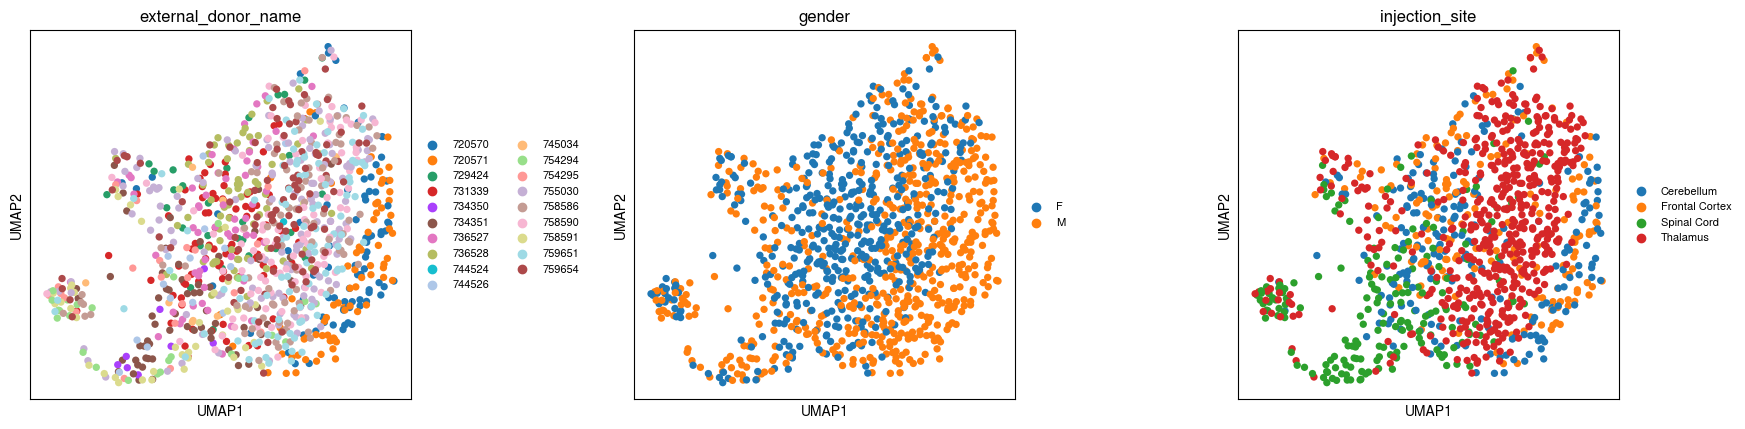

In [8]:
#umap 

sc.pp.neighbors(adata_retro, use_rep='X_pca')#, n_neighbors=50)
sc.tl.umap(adata_retro, random_state=210)

# Plot UMAP with metadata
ax = sc.pl.umap(adata_retro, color=["external_donor_name", "gender", 'injection_site'], 
           ncols=3, show=False)
for a in ax:
    a.set_aspect('equal')

In [9]:
# Clean projection target Categories
# Define categories and handle thalamus
cate_list = ["Frontal Cortex", 'Cerebellum', "Spinal Cord", 'Thalamus']
adata_retro.obs['injection_site'].replace('thalamus', np.nan, inplace=True)
adata_retro.obs['injection_site'] = adata_retro.obs['injection_site'].astype('category')
adata_retro.obs['injection_site'] = adata_retro.obs['injection_site'].cat.remove_unused_categories()
adata_retro.uns.pop('injection_site_colors', None)
adata_retro.obs["injection_site"] = pd.Categorical(
    adata_retro.obs["injection_site"],
    categories=cate_list[:-1],
    ordered=True
)
print("projection target:")
print(adata_retro.obs['injection_site'].value_counts())

# Create color dictionary
cm = plt.cm.get_cmap('tab10')
default_colors = list(cm.colors)
col_list = default_colors[:3]
col_dict = {cate_list[i]: col_list[i] for i in range(len(cate_list))[:3]}
col_dict['others'] = 'white'

projection target:
injection_site
Cerebellum        210
Spinal Cord       183
Frontal Cortex    173
Name: count, dtype: int64


/tmp/ipykernel_12147/3789219233.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap('tab10')


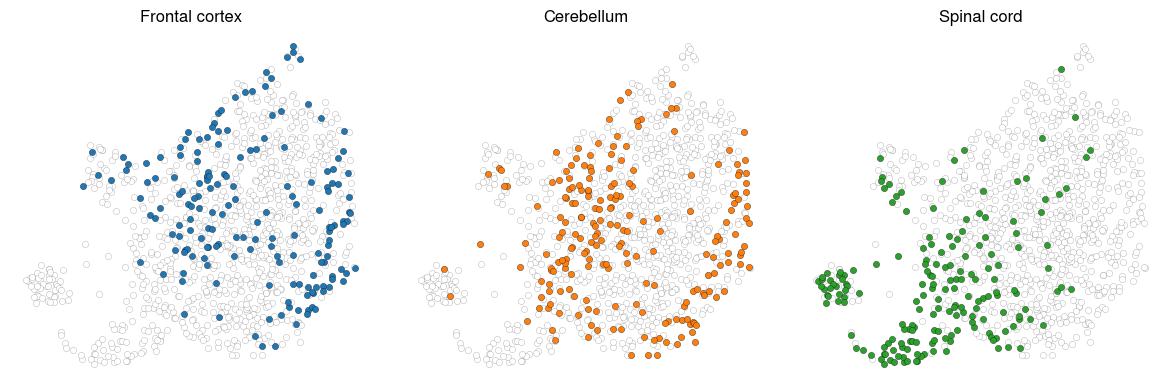

In [10]:
# projection target Visualization on UMAP
umap_coords = adata_retro.obsm['X_umap']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for m, k in enumerate(cate_list[:-1]):
    ax = axes[m]
    # Plot all cells in white
    ax.scatter(umap_coords[:, 0], umap_coords[:, 1], 
               color='white', s=20, alpha=1, label='_nolegend_',
               edgecolor='k', linewidth=.1)
    mask = adata_retro.obs['injection_site'] == k
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1], 
               color=col_dict[k], s=20, alpha=1, label=k,
               edgecolor='k', linewidth=.2)
    ax.set_aspect('equal')
    ax.set_title(k.capitalize())
    ax.set_xticks([]);ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.95])

# run pca for checking

### this is how it was done for 10x data

/tmp/ipykernel_12147/2054574511.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


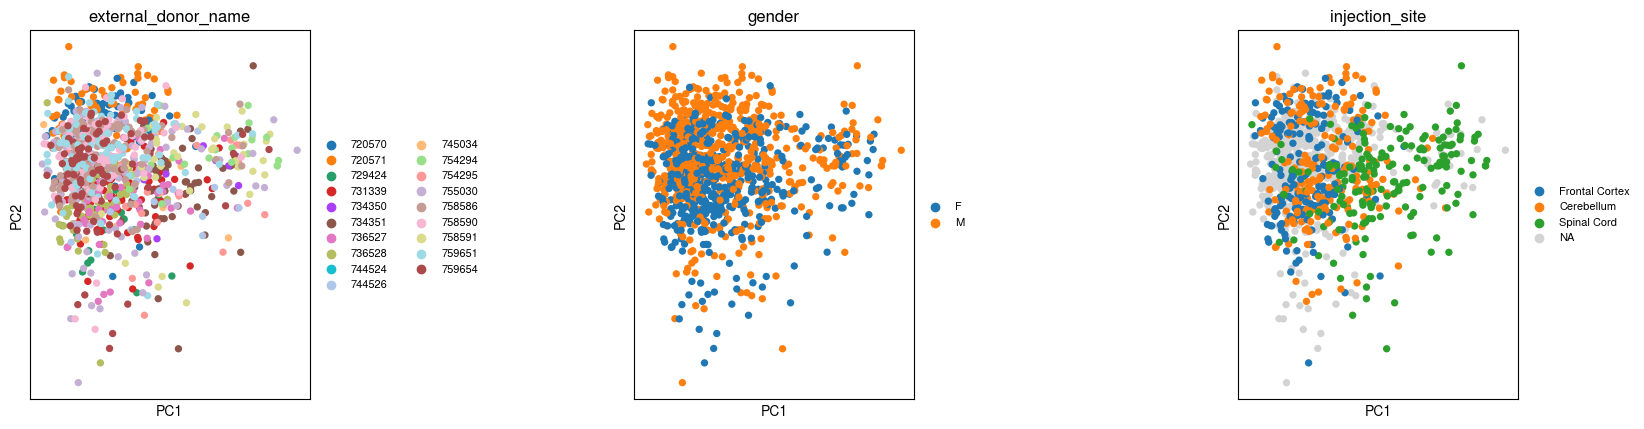

In [11]:

adata_pca = adata_retro.copy()
sc.pp.normalize_total(adata_pca, target_sum=1e6)  # <- change this!
sc.pp.log1p(adata_pca)
sc.pp.scale(adata_pca, zero_center=True, max_value=10)
sc.tl.pca(adata_pca, n_comps=50, svd_solver='arpack')

ax = sc.pl.pca(adata_pca,
    color=["external_donor_name", "gender", "injection_site"],ncols=3,show=False)
for a in ax:
    a.set_aspect("equal")
plt.tight_layout()

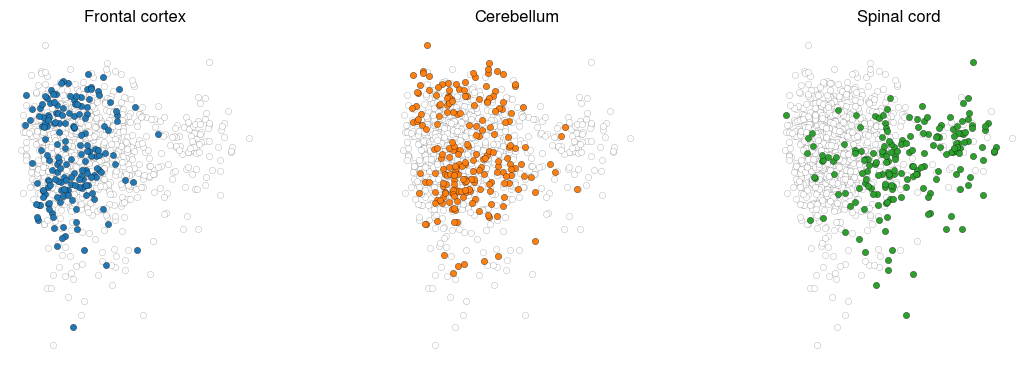

In [12]:
# projection target Visualization on UMAP
pca_coords = adata_pca.obsm['X_pca']
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for m, k in enumerate(cate_list[:-1]):
    ax = axes[m]
    # Plot all cells in white
    ax.scatter(pca_coords[:, 0], pca_coords[:, 1], 
               color='white', s=20, alpha=1, label='_nolegend_',
               edgecolor='k', linewidth=.1)
    mask = adata_retro.obs['injection_site'] == k
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1], 
               color=col_dict[k], s=20, alpha=1, label=k,
               edgecolor='k', linewidth=.2)
    ax.set_aspect('equal')
    ax.set_title(k.capitalize())
    ax.set_xticks([]);ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.95])


# DE analysis 

## (1) pseudobulk with manual t-test -> Abandoned (code below is commented out)
**reasons**
1. assumes normality
2. assumes equal variance
3. replicates are small numbers (3-8 mice/site)

The t-test path is disabled. We keep only the pseudobulk *count* aggregation
(needed by DESeq2 below) and use **DESeq2** (section 2) as the differential-expression
method. See the "DESeq2 improvement recommendations" markdown after section 2.

In [13]:
MOUSE_COL  = "external_donor_name"
groupby_col = 'injection_site'

# --- pseudobulk COUNTS only (needed by DESeq2 in section 2) ---
# use_raw=True -> sums the raw integer read counts preserved in adata_retro.raw
# (NOT the TPM/length-normalized adata_retro.X), which is what DESeq2 expects.
# covariate_cols=["gender"] carries sex into pb_meta so DESeq2 can adjust for it
# (gender is constant within a mouse, so the per-group .first() is exact).
pb_expr, pb_meta = pseudobulk.make_pseudobulk(
    adata_retro, target_col=groupby_col, mouse_col=MOUSE_COL,
    agg="sum", use_raw=True, covariate_cols=["gender"],
)

## (2) pseudobulk with DESeq2 (prob preferred way )
- using DEseq2 is NB (overdispersed expression) for the counts data, which is good 
- also uses empirical bayes, which  borrows information across (otherwise since replicates are so few each gene variance is bad, per gene t-test would be too noisy)

In [14]:
# Single multi-factor DESeq2 model over ALL three sites:
#   design ~ gender + injection_site
# Dispersion is estimated ONCE across all samples (more stable at 3-8 mice/site
# than re-pooling a heterogeneous "Other" group per target); gender is adjusted
# out; low-count genes are pre-filtered; NaN-site (thalamus) samples are dropped.
# Each site's effect is a one-vs-rest contrast (site vs mean of the other two).
deseq_out = pseudobulk.run_deseq2_multifactor_one_vs_rest(
    pb_expr=pb_expr,
    pb_meta=pb_meta,
    groupby_col=groupby_col,
    covariate_cols=["gender"],
    min_total_count=10,
    n_cpus=4,
    quiet=True,
)
print("reference site (auto-detected):", deseq_out["reference_site"])
print("genes kept after low-count filter:", len(deseq_out["genes_kept"]))

# enriched genes per site -> top_genes_dict_deseq (all three sites now populated)
site_order = ['Frontal Cortex', 'Cerebellum', 'Spinal Cord']
top_genes_dict_deseq = {
    site: pseudobulk.filter_deseq_enriched(
        deseq_out["results_by_site"][site], lfc_thr=1.0, padj_thr=0.05
    ).index.astype(str).tolist()
    for site in site_order
}

for site in site_order:
    print(f"{site:>15}: {len(top_genes_dict_deseq[site]):3d} enriched genes (LFC>1, padj<0.05)")

/code/pseudobulk.py:377: UserWarning: Dropping 5 pseudobulk sample(s) with NaN 'injection_site'.
  warnings.warn(f"Dropping {n_drop_site} pseudobulk sample(s) with NaN '{groupby_col}'.")


reference site (auto-detected): Cerebellum
genes kept after low-count filter: 1023
 Frontal Cortex:   3 enriched genes (LFC>1, padj<0.05)
     Cerebellum:   0 enriched genes (LFC>1, padj<0.05)
    Spinal Cord:  39 enriched genes (LFC>1, padj<0.05)


In [15]:
print(list(top_genes_dict_deseq['Spinal Cord']))

['Shox2', 'Tacr3', 'Grpr', 'Fcer1g', 'Syndig1', 'Hoxb2', 'Gpc3', 'Adamts16', 'Nfia', 'Rspo2', 'Crb1', 'Galnt14', 'Grik1', 'Pappa2', 'Abca6', 'Plxdc2', 'Dscaml1', 'Htr2a', 'Cntn3', 'Tshr', 'Lhfpl3', 'Pard3b', 'B4galnt3', 'Tshz2', 'Olfr78', 'Ret', 'Pcdh7', 'Rbfox3', 'Tmem132d', 'Pla2g4d', 'Tgfb2', 'Myo16', 'Parm1', 'Nol4', 'Dpp10', 'Kalrn', 'Gabbr2', 'Cpne4', 'Gabrg1']


# impute the projection for the snRNAseq data

In [16]:
# just load snRNA data 
adata_sc_foo = sc.read_h5ad(os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad"))
adata_sc_foo = adata_sc_foo[:,keepgenes]  # this step is really important if you just want to assume teh same order genes!!!
adata_sc_BN = adata_sc_foo.copy()
adata_sc_BN.X = adata_sc_foo.layers['BN'].copy()
adata_sc_BN.raw = adata_sc_BN.copy()

arc_path = TMP_OUT_DIR+'/cell_ID_peudocluster.csv'
arcinfo = pd.read_csv(arc_path)
arcinfo = arcinfo.set_index('cellID')
adata_sc_BN.obs['pc'] = arcinfo['pseudoclusters'].reindex(adata_sc_BN.obs.index)


In [17]:
order = cate_list[:-1]
palette = dict(zip(order, sns.color_palette('tab10', len(order))))


In [18]:
use_batchcorrected = False # avoiding any scvi induced artifact. 

adata_sc_foo = sc.read_h5ad(os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad"))
adata_sc_foo = adata_sc_foo[:,keepgenes]  # this step is really important if you just want

if use_batchcorrected:  ### both batch corrected
    X_sc =adata_sc_BN[:,keepgenes].X  # normalized
#     X_retro = adata_retro.layers['BN'].astype(float)    
    X_retro = adata_retro[:,keepgenes].X.astype(float)  
else:    ### raw!!
    X_sc =adata_sc_foo[:,keepgenes].X  # this is literally raw counts
    X_retro = adata_retro[:,keepgenes].X.astype(float)  #this is length normalized but raw counts (thats why they sum to 1M)

X_sc_norm = processing.rankrows(X_sc,standardize = True)
X_retro_norm = processing.rankrows(X_retro,standardize = True)

k = 10
percentage_thre = .8 #  >= this percentage value will be considered to be valid imputations
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_retro_norm)
distances, indices = nbrs.kneighbors(X_sc_norm) # distance: size (N_snRNA, K)
print(distances.shape, indices.shape) # for each snRNAseq, find k best retroseq cells
allprojections = np.array(adata_retro.obs['injection_site'].values)

imputed_projections = []
disagreement_scores = []
for i in range(X_sc_norm.shape[0]):
    neighbor_idx = indices[i]  # length K
    neighbor_projections = allprojections[neighbor_idx]
    valid_projections = neighbor_projections[~pd.isna(neighbor_projections)]
    
    if len(valid_projections) == 0:
        imputed_projections.append(np.nan)
        disagreement_scores.append(1.0)  # Maximum disagreement
    else:
        unique_targets, counts = np.unique(valid_projections, return_counts=True)
        max_count = np.max(counts)
        max_target = unique_targets[np.argmax(counts)]
        
        if max_count >= int(percentage_thre*len(valid_projections)): # can change this 
            imputed_projections.append(max_target)
        else:
            imputed_projections.append(np.nan)
        
        # Compute disagreement score based on valid neighbors only
        disagreement_score = 1 - (max_count / len(valid_projections)) 
        disagreement_scores.append(disagreement_score)

adata_sc_BN.obs['imputed_projection'] = imputed_projections
adata_sc_BN.obs['disagreement_score'] = disagreement_scores
adata_sc_BN.obs["imputed_projection"] = pd.Categorical(adata_sc_BN.obs["imputed_projection"], # change the color 
                                                       categories=cate_list[:-1],ordered=True)


# also add for the visualization of total expressions of these genes 
adata_sc_foo = sc.read_h5ad(os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_1-5k.h5ad"))
# adata_sc_BN.obs['spinalcord_enrichedgenes'] = np.sum(adata_sc_foo[:,finalist_genes].X,1)  # raw counts sum


(4743, 10) (4743, 10)


Saving figure to: /results/figures/retroseq/fig_S11c.svg
Saving figure to: /results/figures/retroseq/fig_S11c.png
Saving source data to: /results/figures/retroseq/fig_S11c_source_data.csv
[verify] fig_S11c: PASS  (PASS=4 FAIL=0 WARN=1; bg={'mesh': 0, 'gray_scatter': 0, 'colorbar': 0, 'constant_line': 0}; unmatched_artists=8)
    [PASS            ]                        disagreement_score         value       PathCollection n=4743 8.33e-17
    [PASS            ]                        pseudocluster              value       PathCollection n=4743 0.00e+00
    [PASS            ]                        UMAP1                      coord       PathCollection n=4743 4.76e-07
    [PASS            ]                        UMAP2                      coord       PathCollection n=4743 2.38e-07
    [WARN(provenance)]                        imputed_projection         categorical -              n=4743 


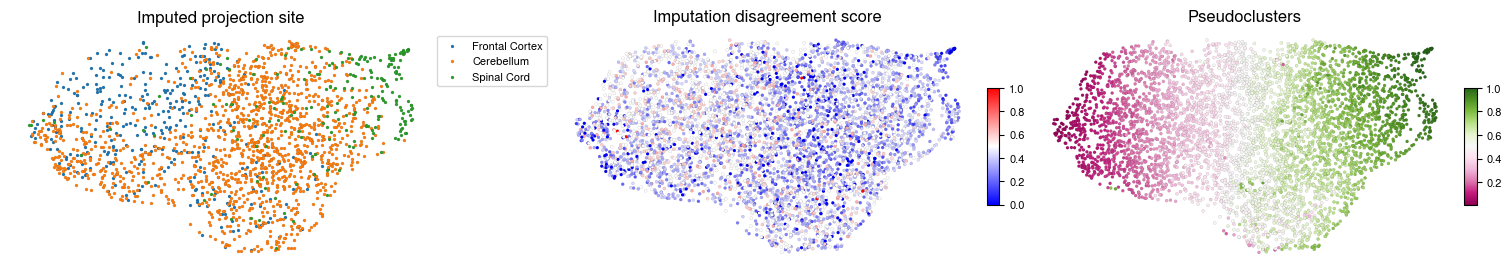

In [19]:
s=5; lw=.05
fig, axes = plt.subplots(1, 3, figsize=(15,4), constrained_layout=True)
ax = axes[0]
for c in cate_list[:-1]:
    ax.scatter(adata_sc_BN.obsm['X_umap'][adata_sc_BN.obs['imputed_projection']==c, 0],
               adata_sc_BN.obsm['X_umap'][adata_sc_BN.obs['imputed_projection']==c, 1],
               s=s, color=palette[c], edgecolor='k', linewidth=lw, label = c)
for spine in ax.spines.values(): spine.set_visible(False)
ax.legend(bbox_to_anchor=(1, 1))
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Imputed projection site')
ax.set_aspect('equal')

ax = axes[1]
sca1 = ax.scatter(adata_sc_BN.obsm['X_umap'][:, 0], adata_sc_BN.obsm['X_umap'][:, 1],
                 s=s, c=adata_sc_BN.obs['disagreement_score'].values,
                 cmap='bwr', edgecolor='k', linewidth=lw,vmin = 0,vmax=1)
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Imputation disagreement score')
ax.set_aspect('equal')

ax = axes[2]
sca2 = ax.scatter(adata_sc_BN.obsm['X_umap'][:, 0], adata_sc_BN.obsm['X_umap'][:, 1],
           s=s, c=adata_sc_BN.obs['pc'].values,
           cmap='PiYG', edgecolor='k', linewidth=lw)
for spine in ax.spines.values(): spine.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_title('Pseudoclusters')
ax.set_aspect('equal')
cax = axes[1].inset_axes([1.02, 0.25, 0.03, 0.5])  # [x0,y0,w,h] in axes coords
fig.colorbar(sca1, cax=cax)
cax = axes[2].inset_axes([1.02, 0.25, 0.03, 0.5])  # [x0,y0,w,h] in axes coords
fig.colorbar(sca2, cax=cax)
src_umap = pd.DataFrame(adata_sc_BN.obsm['X_umap'][:, :2], columns=["UMAP1", "UMAP2"],
                        index=adata_sc_BN.obs_names)
src_umap["imputed_projection"] = adata_sc_BN.obs['imputed_projection'].values
src_umap["disagreement_score"] = adata_sc_BN.obs['disagreement_score'].values
src_umap["pseudocluster"] = adata_sc_BN.obs['pc'].values
save_figure('fig_S11c', source_data=src_umap)
plt.show()

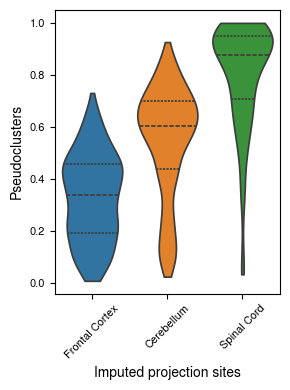

Saving figure to: /results/figures/retroseq/fig_3d_retro.svg
Saving figure to: /results/figures/retroseq/fig_3d_retro.png


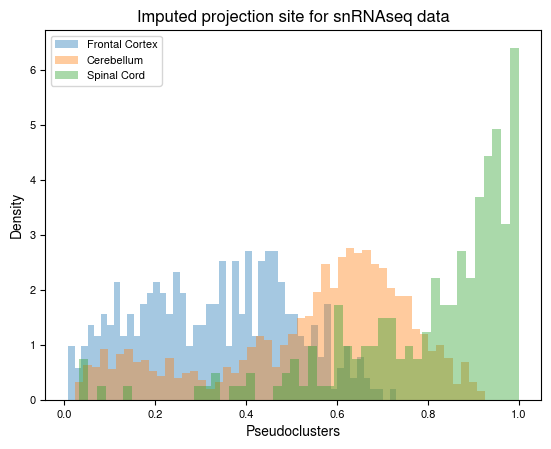

In [20]:
order = cate_list[:-1]
palette = dict(zip(order, sns.color_palette('tab10', len(order))))
plt.figure(figsize = (3,4))
sns.violinplot(
    data=adata_sc_BN.obs,
    x='imputed_projection',
    y='pc',
    order=order,
    palette=palette,
    cut=0,
    inner='quartile'
)
plt.xticks(rotation=45)
plt.xlabel('Imputed projection sites')
plt.ylabel('Pseudoclusters')
plt.tight_layout()
src_violin = pd.DataFrame(
    {"imputed_projection": adata_sc_BN.obs['imputed_projection'].values,
     "pseudocluster": adata_sc_BN.obs['pc'].values},
    index=adata_sc_BN.obs_names)
# save_figure('projection_imputation_results_violin', source_data=src_violin)
plt.show()

for c in cate_list[:-1]:
    plt.hist(adata_sc_BN.obs.loc[adata_sc_BN.obs['imputed_projection'] == c, 'pc'],
             bins=50, alpha=0.4, density=True, label=c, color=palette[c])
plt.legend()
plt.xlabel('Pseudoclusters');plt.ylabel('Density')
plt.title('Imputed projection site for snRNAseq data')
save_figure('fig_3d_retro')
plt.show()


# some sort of statistical test
- ANOVA has normal residual assumptions. here is skewed, bounded, diff varainces

- so non-parametric version, rank-based analogue of ANOVA: kruskal-wallis 

In [21]:
order = cate_list[:-1]
# collect score vectors in the same order as the plot
groups = [
    adata_sc_BN.obs.loc[adata_sc_BN.obs['imputed_projection'] == c, 'pc'].dropna().values
    for c in order
]

# overall Kruskal–Wallis test
H, p = kruskal(*groups)

print(f"Kruskal-Wallis H = {H:.4f}")
print(f"P-value = {p:.3e}")

Kruskal-Wallis H = 544.9916
P-value = 4.535e-119


In [ ]:
print("Analysis complete! All visualizations have been saved to:", fig_path)

Analysis complete! All visualizations have been saved to: /results/figures/retroseq


: 